In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from gymnasium.wrappers import RecordVideo

In [11]:
NUM_EPISODES = 100000
EPSILON = np.linspace(0.9, 0.1, NUM_EPISODES)
DISCOUNT = 0.9
ALPHA = 0.1

In [12]:
def train(env):
    obs_dim = env.observation_space.n
    act_dim = env.action_space.n

    Q = np.zeros((obs_dim, act_dim))
    reward_history = []

    for i, eps in enumerate(EPSILON):
        done = False
        total_reward = 0
        state, info = env.reset()
        action = np.argmax(Q[state]) if np.random.rand() > eps else env.action_space.sample()

        while not done:
            next_state, reward, terminated, truncated, info = env.step(action)
            next_action = np.argmax(Q[next_state]) if np.random.rand() > eps else env.action_space.sample()
            
            Q[state, action] += ALPHA * (
                reward + DISCOUNT * Q[next_state, next_action] - Q[state, action]
            )

            total_reward += reward

            state = next_state
            action = next_action
            done = terminated or truncated

        reward_history.append(total_reward)

        # if not (i + 1) % 1000:
        #     print(f"Episode: {i+1}/{NUM_EPISODES}, Total reward: {total_reward}")

    return Q, reward_history

# Stochastic

In [ ]:
env = gym.make("CliffWalking-v1", is_slippery=True)
Q, reward_history = train(env)

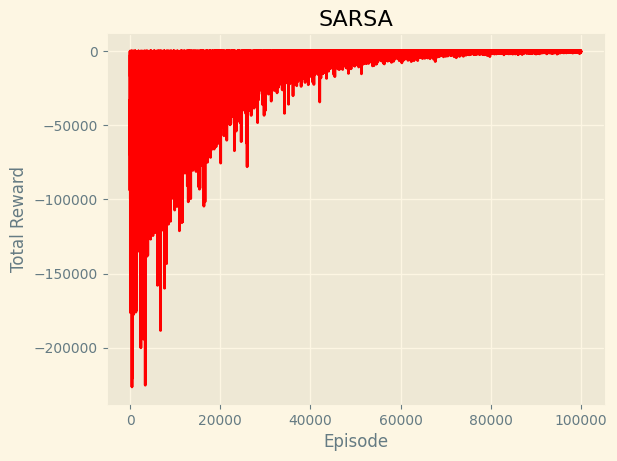

In [14]:
reward_history = np.load("../experiments/sarsa_stochastic_rh.npy")
plt.style.use("Solarize_Light2")
plt.plot(reward_history, color="red")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("SARSA")
plt.show()

In [ ]:
np.save('../experiments/sarsa_stochastic_rh.npy', reward_history)
np.save('../experiments/sarsa_stochastic_ag.npy', Q)

# Deterministic

In [ ]:
env = gym.make("CliffWalking-v1", is_slippery=False)
Q, reward_history = train(env)

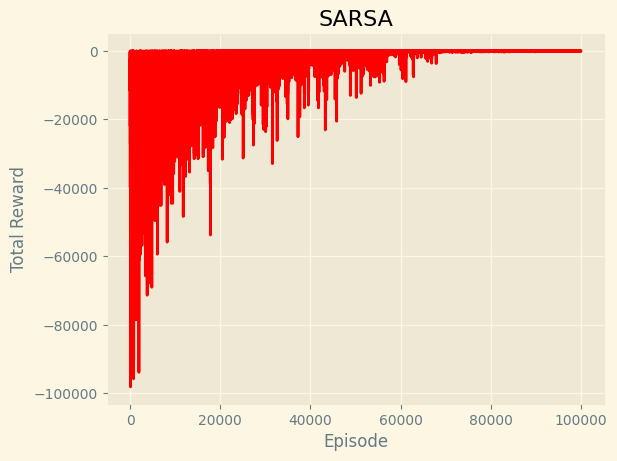

In [6]:
plt.style.use("Solarize_Light2")
plt.plot(reward_history, color="red")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("SARSA")
plt.show()

In [7]:
np.save('../experiments/sarsa_deterministic_rh.npy', reward_history)
np.save('../experiments/sarsa_deterministic_ag.npy', Q)

# Evaluation

In [5]:
Q = np.load('../results/checkpoints/sarsa_deterministic_q.npy')

In [ ]:
eval_env = gym.make("CliffWalking-v1", is_slippery=False, render_mode="rgb_array")
eval_env = RecordVideo(eval_env, video_folder="../results/videos", name_prefix="sarsa_deterministic", episode_trigger=lambda x: True)

observation, info = eval_env.reset(seed=42)
terminated = False
while not terminated:
    action = np.argmax(Q[observation])
    observation, reward, terminated, truncated, info = eval_env.step(action)

    if truncated:
        observation, info = eval_env.reset()

eval_env.close()

Head over to `q_learning.ipynb` to see comparisons